In [1]:
import anndata as ad
import pandas as pd
from itertools import combinations
import numpy as np

# Number of cores to use
ncores = 64

import sys

import anndata
#from netmap.downstream import final_downstream
from netmap.downstream.edge_selection import *
from netmap.downstream.clustering import *
#from netmap.downstream.final_downstream import *
from netmap.downstream.plotting import *

from netmap.downstream.regulon import *
import warnings

from netmap.utils.data_utils import *
from netmap.utils.tf_utils import *
from netmap.utils.netmap_config import NetmapConfig

from netmap.model.train_model import create_model_zoo
from netmap.grn.inferrence import inferrence, inferrence_model_wise
from netmap.masking.internal import *
from netmap.masking.external import *


import scipy.sparse as scs


import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

import yaml


def save_clustering_score_to_yaml(analysis_output_dir, score):
    data = {'clustering_score': float(score) }
    with open(op.join(analysis_output_dir, 'clustering_score.yaml'), 'w') as file:
        yaml.dump(data, file, default_flow_style=False)

In [2]:
collectri = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/input_network/collectri.tsv', sep = '\t')
adata_raw = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/cd8tcells.h5ad')
experiment_name = 'cd8_tcells'
output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/cd8_usecase_low_ui/"
var = pd.read_csv(op.join(output_dir, f'{experiment_name}_var.tsv'))
obs = pd.read_csv(op.join(output_dir, f'{experiment_name}_obs.tsv'))
grn_adata = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)

In [3]:
analysis_output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/{experiment_name}"
os.makedirs(analysis_output_dir, exist_ok=True)

In [4]:
analysis_output_dir = op.join(output_dir, )
grn_output_dir = Path(op.join(output_dir, "grn"))

## load data
Get the top 10 percent of the egdes by global weight, to perform the clustering on. These will be discarded again, and replaced by better edges.

In [5]:
grn_adata = retrieve_top_edges(grn_adata, grn_output_dir, percentage=0.1, inplace=True)
grn_adata.var = grn_adata.var.set_index('index')


## Cluster the anndata object with the gene expression data.

In [6]:
sc.tl.pca(adata_raw, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(adata_raw, n_neighbors = 50)
sc.tl.umap(adata_raw, n_components =50)
sc.tl.leiden(adata_raw, resolution=0.15)


## Embedd data using standard embedding to get the clustering
Here you can set a higher resolution, it will map clusters accordingly. 
These clusters will be selected to find edges which are 'highly expressed' in a local neighborhood.

In [7]:
sc.tl.pca(grn_adata, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata, n_neighbors = 50)
sc.tl.umap(grn_adata, n_components =50)
sc.tl.tsne(grn_adata)
sc.tl.leiden(grn_adata, resolution=0.8)

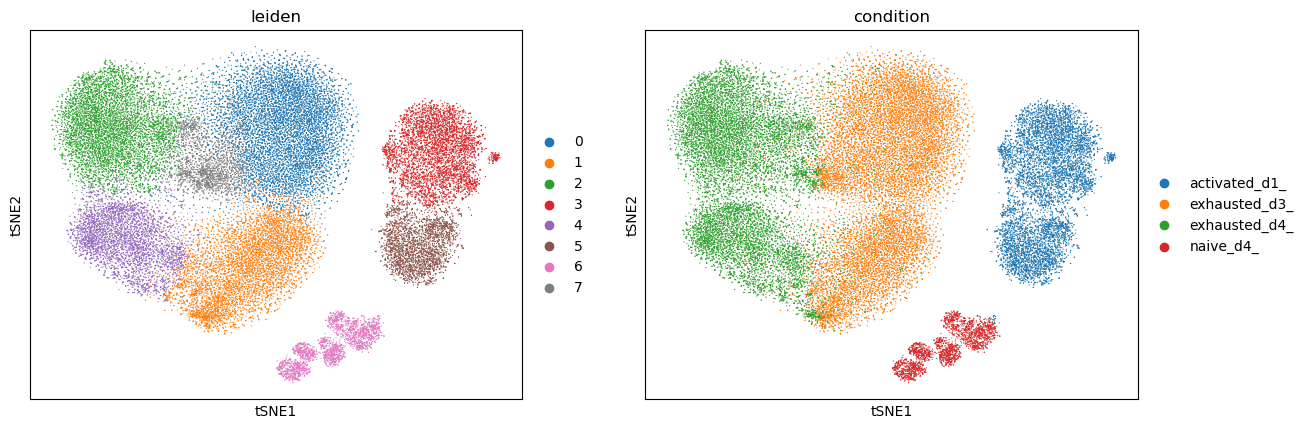

In [8]:

with plt.rc_context(): 
    sc.pl.tsne(grn_adata, color = ['leiden', 'condition'], show=False)
    plt.savefig(op.join(analysis_output_dir, 'grn_clustering_comparison_tsne.pdf'), bbox_inches="tight")

## Check how well the clustering is concordant with the gene expression clustering
The score indicated how many cells are 'correctly' assigned between the gene expression clustering and the gene expression clustering.
It varies between 1/n_clusters (random assignment) and 1 (perfect identical clustering.)

In [9]:
print("\nClustering Score Evaluation")
score, mapping = unify_group_labelling(  adata_raw,grn_adata, 'condition', 'leiden', True)
print(score)
save_clustering_score_to_yaml(analysis_output_dir, score)


Clustering Score Evaluation
0.9373312357651037


In [10]:
# Add the gene expression based clustering back to the GEX expression object.
adata_raw.obs['celltype_remapped'] = grn_adata.obs['leiden_remap'].values


## Make a new anndata object, loading more interesting edges per cluster

### Load only viable edges which have reasonable expression of the base edges.
We previously clustered the data into smaller groups, now we are loading edges which are interesting in that group. We only load edges where the underlying pairs of genes are expressed in a minimum percentage of cells together.

Note: The cluster column you select here should remain consistent throughout the notebook.

In [11]:
# compute neighborhood expression mask to get the 

cluster_column = 'leiden'
add_neighbourhood_expression_mask(adata_raw, grn_adata, strict=False, layer = 'counts' )
grn_adata = add_cluster_based_candidate_edges(grn_adata, threshold=0.01, cluster_column=cluster_column)


In [12]:
# get informative eges and replace the anndata object with the new data.
# Choose inplace =true to update the edges 
index_list = np.where(grn_adata.var['candidate_edge'])[0]
grn_adata = retrieve_edges_by_index(grn_adata, grn_output_dir, index_list, inplace=True)

## Recluster the data
Now that we have loaded reliable edges, we can recluster the data to see if we are still in line with the gene expression clustering.

In [13]:
sc.tl.pca(grn_adata, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata, n_neighbors = 50)
sc.tl.umap(grn_adata, n_components =50)
sc.tl.tsne(grn_adata)

In [14]:
sc.tl.leiden(grn_adata, resolution=0.15)

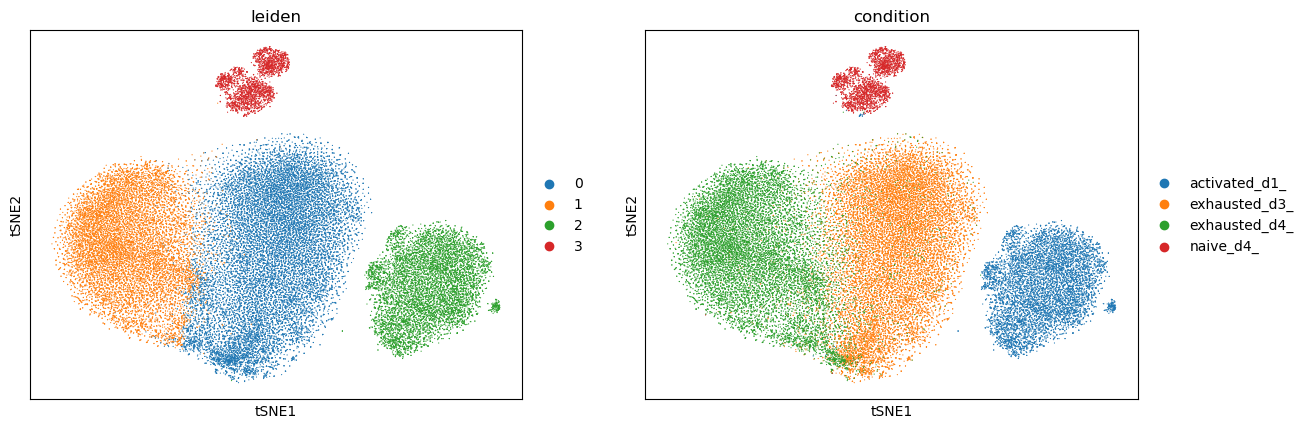

In [15]:

with plt.rc_context(): 
    sc.pl.tsne(grn_adata, color = ['leiden', 'condition'], show=False)
    plt.savefig(op.join(analysis_output_dir, 'grn_clustering_comparison_tsne.pdf'), bbox_inches="tight")
plt.show()

In [16]:
#### Show the assignment confusion matrix.

In [17]:
cross_tab = pd.crosstab( grn_adata.obs['condition'],  grn_adata.obs['leiden_remap'])

In [18]:
cross_tab

leiden_remap,activated_d1_,exhausted_d3_,exhausted_d4_,naive_d4_
condition,,,,
activated_d1_,8629,11,1,24
exhausted_d3_,0,16936,265,0
exhausted_d4_,3,2356,11677,3
naive_d4_,0,3,3,2678


## Add an external annotation GRN if desired
Make sure that the gene names in the GRN are compatible with the gene names in the data.

In [19]:
 grn_adata = add_external_grn(grn_ad= grn_adata, external_grn=collectri,name_grn='collectri')

In [20]:
# Identify top targets for each source gene within clusters
# - Keeps up to top_per_source strongest targets
# - Removes regulons smaller than min_reg_size

add_neighbourhood_expression_mask(adata_raw,  grn_adata, strict=False, layer = 'counts' )



AnnData object with n_obs × n_vars = 42589 × 61201
    obs: 'Unnamed: 0', 'cell_id', 'condition', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'leiden_remap'
    var: 'source', 'target', 'edge_sums', 'edge_means', 'count_nonzero', 'count_nonzero_norm', '0_nonzero', '0_candidate_edge', '1_nonzero', '1_candidate_edge', '2_nonzero', '2_candidate_edge', '3_nonzero', '3_candidate_edge', '4_nonzero', '4_candidate_edge', '5_nonzero', '5_candidate_edge', '6_nonzero', '6_candidate_edge', '7_nonzero', '7_candidate_edge', 'candidate_edge', 'edge_in_collectri', 'is_target_collectri', 'is_source_collectri'
    uns: 'edge_sum_origin

## Create regulon signatures by selecting the unique top edges per cluster

In [21]:
tp = 20 # Choose 20 targets per cluster
min_reg_size = 3 #Regulon size lower bound

keep_edges = select_top_edges(gene_inter_adata= grn_adata, adata=adata_raw, top_per_source=tp, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True)
all_regulons = make_cluster_regulon_dataframe(keep_edges)
# Aggregate the regulons by summing over the edges.
regus = aggregate_edges(keep_edges,  grn_adata, key='unique')
# Make a signature anndata object with the aggregated regulon dataframe
all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)
all_signatures.obs[cluster_column] =  grn_adata.obs[cluster_column].values
all_signatures.var['regulon_name'] = all_signatures.var.index.values

# Run differential testing to get the top signatures per group
sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")


Selecting targets for cluster: 0
Selecting targets for cluster: 1
Selecting targets for cluster: 2
Selecting targets for cluster: 3
0
1
2
3


## Save your objects if desired.

In [22]:
grn_adata.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_processed.h5ad'))
all_signatures.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_signatures.h5ad'))

## Plot your regulons in a scanpy-like regulon plot

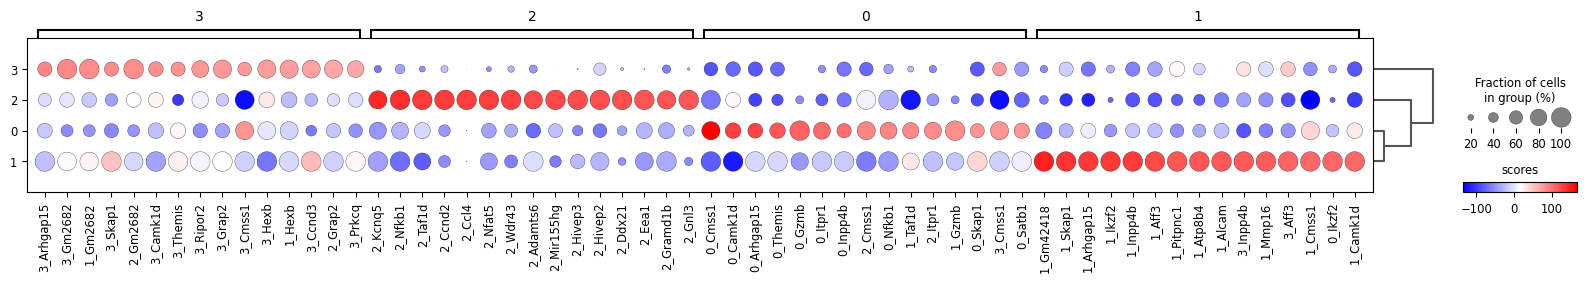

In [23]:
# If you previously computed the edge mask based on a different clustering, you have to recompute
grn_adata = add_cluster_based_candidate_edges(grn_adata, threshold=0.01, cluster_column=cluster_column)

pp = rank_regulon_groups_dotplot( grn_adata, adata_regl=all_signatures, return_fig=True, new_cluster_column=cluster_column,original_cluster_column=cluster_column, n_genes=15, figsize=(20, 2))
pp.show()

## You can plot regulons against each other in a regulon plot to see if they have commonalities.


Get the colors to match between the plots.

In [24]:
# Your existing color mapping logic
color_mapping = dict(zip( grn_adata.obs['leiden'].cat.categories,  grn_adata.uns['leiden_colors']))

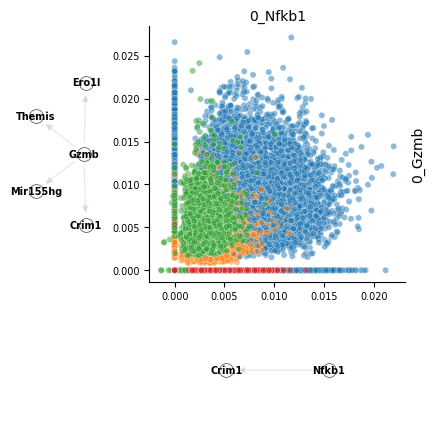

In [25]:
import matplotlib.pyplot as plt
plot_regulon_comparison(all_signatures, all_regulons[all_regulons.set_type == 'unique'], ['0_Nfkb1' , '0_Gzmb' ], show_legend=False, palette=color_mapping, cluster_key=cluster_column)
plt.show()

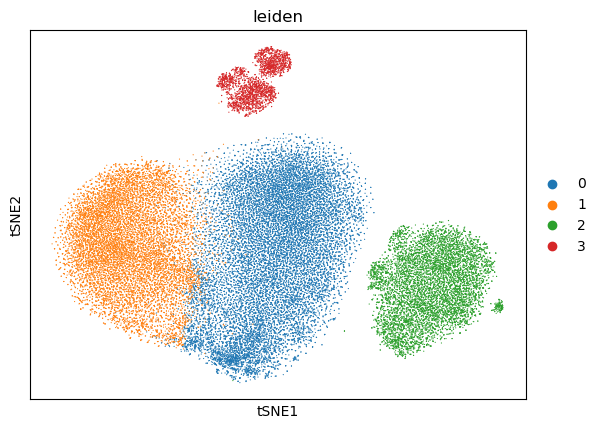

In [26]:
sc.pl.tsne( grn_adata, color = 'leiden')

In [27]:
# Transfer the embedding from the GRN object to the signature object.
all_signatures.obsm['X_tsne'] = grn_adata.obsm['X_tsne']
adata_raw.obsm['X_tsne'] = grn_adata.obsm['X_tsne']

In [28]:
all_signatures.var.index

Index(['0_4933406I18Rik', '0_Abtb2', '0_Adamts6', '0_Add1', '0_Aff3',
       '0_Ahnak', '0_Alcam', '0_Apbb1ip', '0_Arap2', '0_Arhgap15',
       ...
       '3_Ube2h', '3_Vps37b', '3_Wnt5b', '3_Wwox', '3_Xist', '3_Zeb1',
       '3_Znrf1', '3_Znrf2', '3_Znrf3', '3_Zswim6'],
      dtype='object', length=815)

#### Make a regulon activity plot
This plots the signature value (the mean value of all edges in the respective regulon) on the UMAP

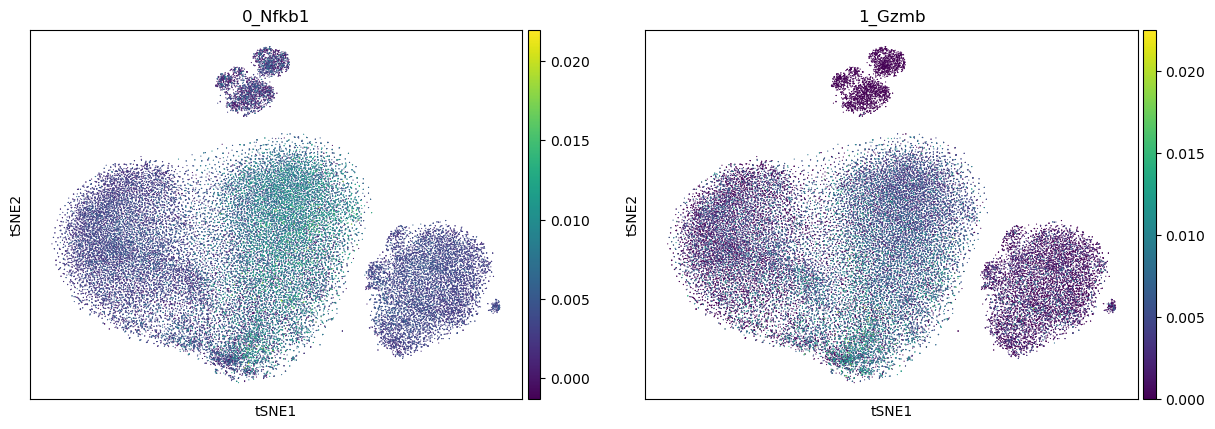

In [29]:
sc.pl.tsne(all_signatures, color = ['0_Nfkb1',  '1_Gzmb'])

#### Verify that the genes are expressed in the respective clusters.
(Plot the standard gene expression data.)

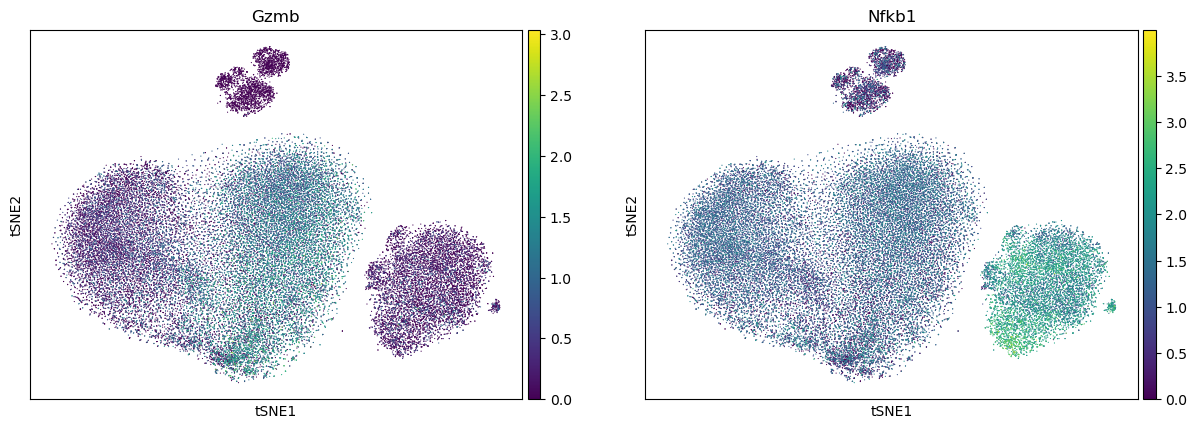

In [30]:
sc.pl.tsne(adata_raw, color = ['Gzmb', 'Nfkb1'])

#### Check in which order the top regulons appear per cell type 
The later the next celltype appears the stronger the cell identity.

In [31]:
bcrank = sc.get.rank_genes_groups_df(all_signatures, group = '0', key  = 'wilcoxon')

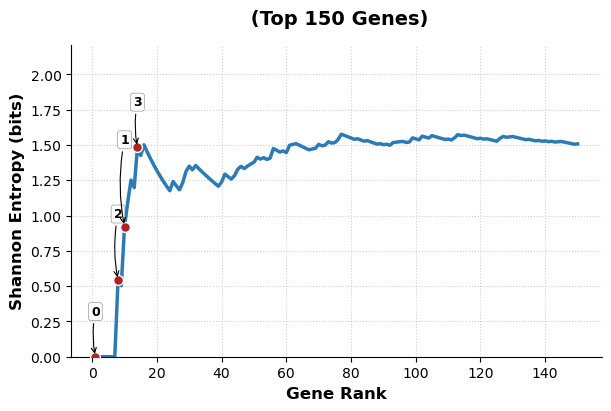

In [32]:
bcrank_entropy(bcrank, top_n=150, title="", figsize=(6,4))

#### Filter the regulons and make a GRN score
We can add up the value of arbitrary edges like for the regulon. Here we take the top 400 edges to make a GRN value for a specific regulon.

In [33]:
# Select the edges
filtered_df = all_regulons[(all_regulons.set_type == 'unique') & (all_regulons.cluster == '0')].nlargest(400,'sum_of_edge')
#Make a list
my_edges = [f'{e1}_{e2}' for (e1,e2) in zip(filtered_df.source.values, filtered_df.target.values)]
# Aggregate the edges
signi = aggregate_edges_arbitrary( grn_adata, {'0': my_edges})
# assign the summarized GRN value to a column in the GRN object for convenient plotting.
grn_adata.obs['0'] = signi['0'].values

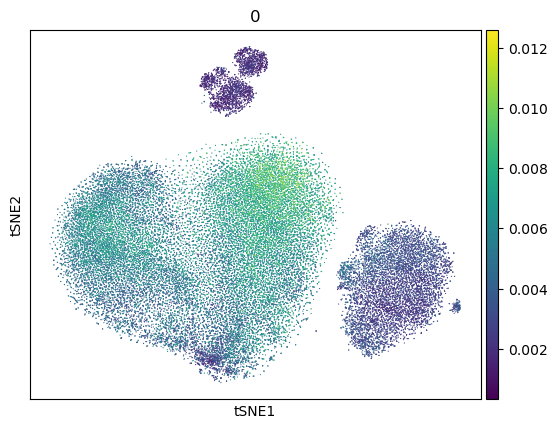

In [34]:
sc.pl.tsne( grn_adata, color = '0' )

In [35]:

import igraph as ig

def make_single_celltype_graph(filtered_df, tfs = None):
    g = ig.Graph.TupleList(filtered_df[['source', 'target', 'sum_of_edge']].itertuples(index=False), directed=False, weights=True)

    # 7. LAYOUT & PLOTTING
    layout = g.layout_kamada_kawai()

    if tfs is not None:
        g.vs["is_tf"] = [name in tfs for name in g.vs["name"]]
        colors = ["#ff7f0e" if is_tf else "#1f77b4" for is_tf in g.vs["is_tf"]]
    else:
        colors = ["#ff7f0e" for node in g.vs["is_tf"]]

    fig, ax = plt.subplots(figsize=(22, 22))

    ig.plot(g, 
    layout=layout,
    target=ax,
    vertex_label_size=11,
        vertex_label_dist=2.0,
        edge_alpha=0.15,
        edge_arrow_size=0.3,
        vertex_color=colors,
        vertex_label=g.vs["name"],
        edge_color = 'lightblue'
        )
    plt.show()

## Show a single network
This can be used to showcase a single network while highlighting some genes (called tfs here, but they can be any type of gene)

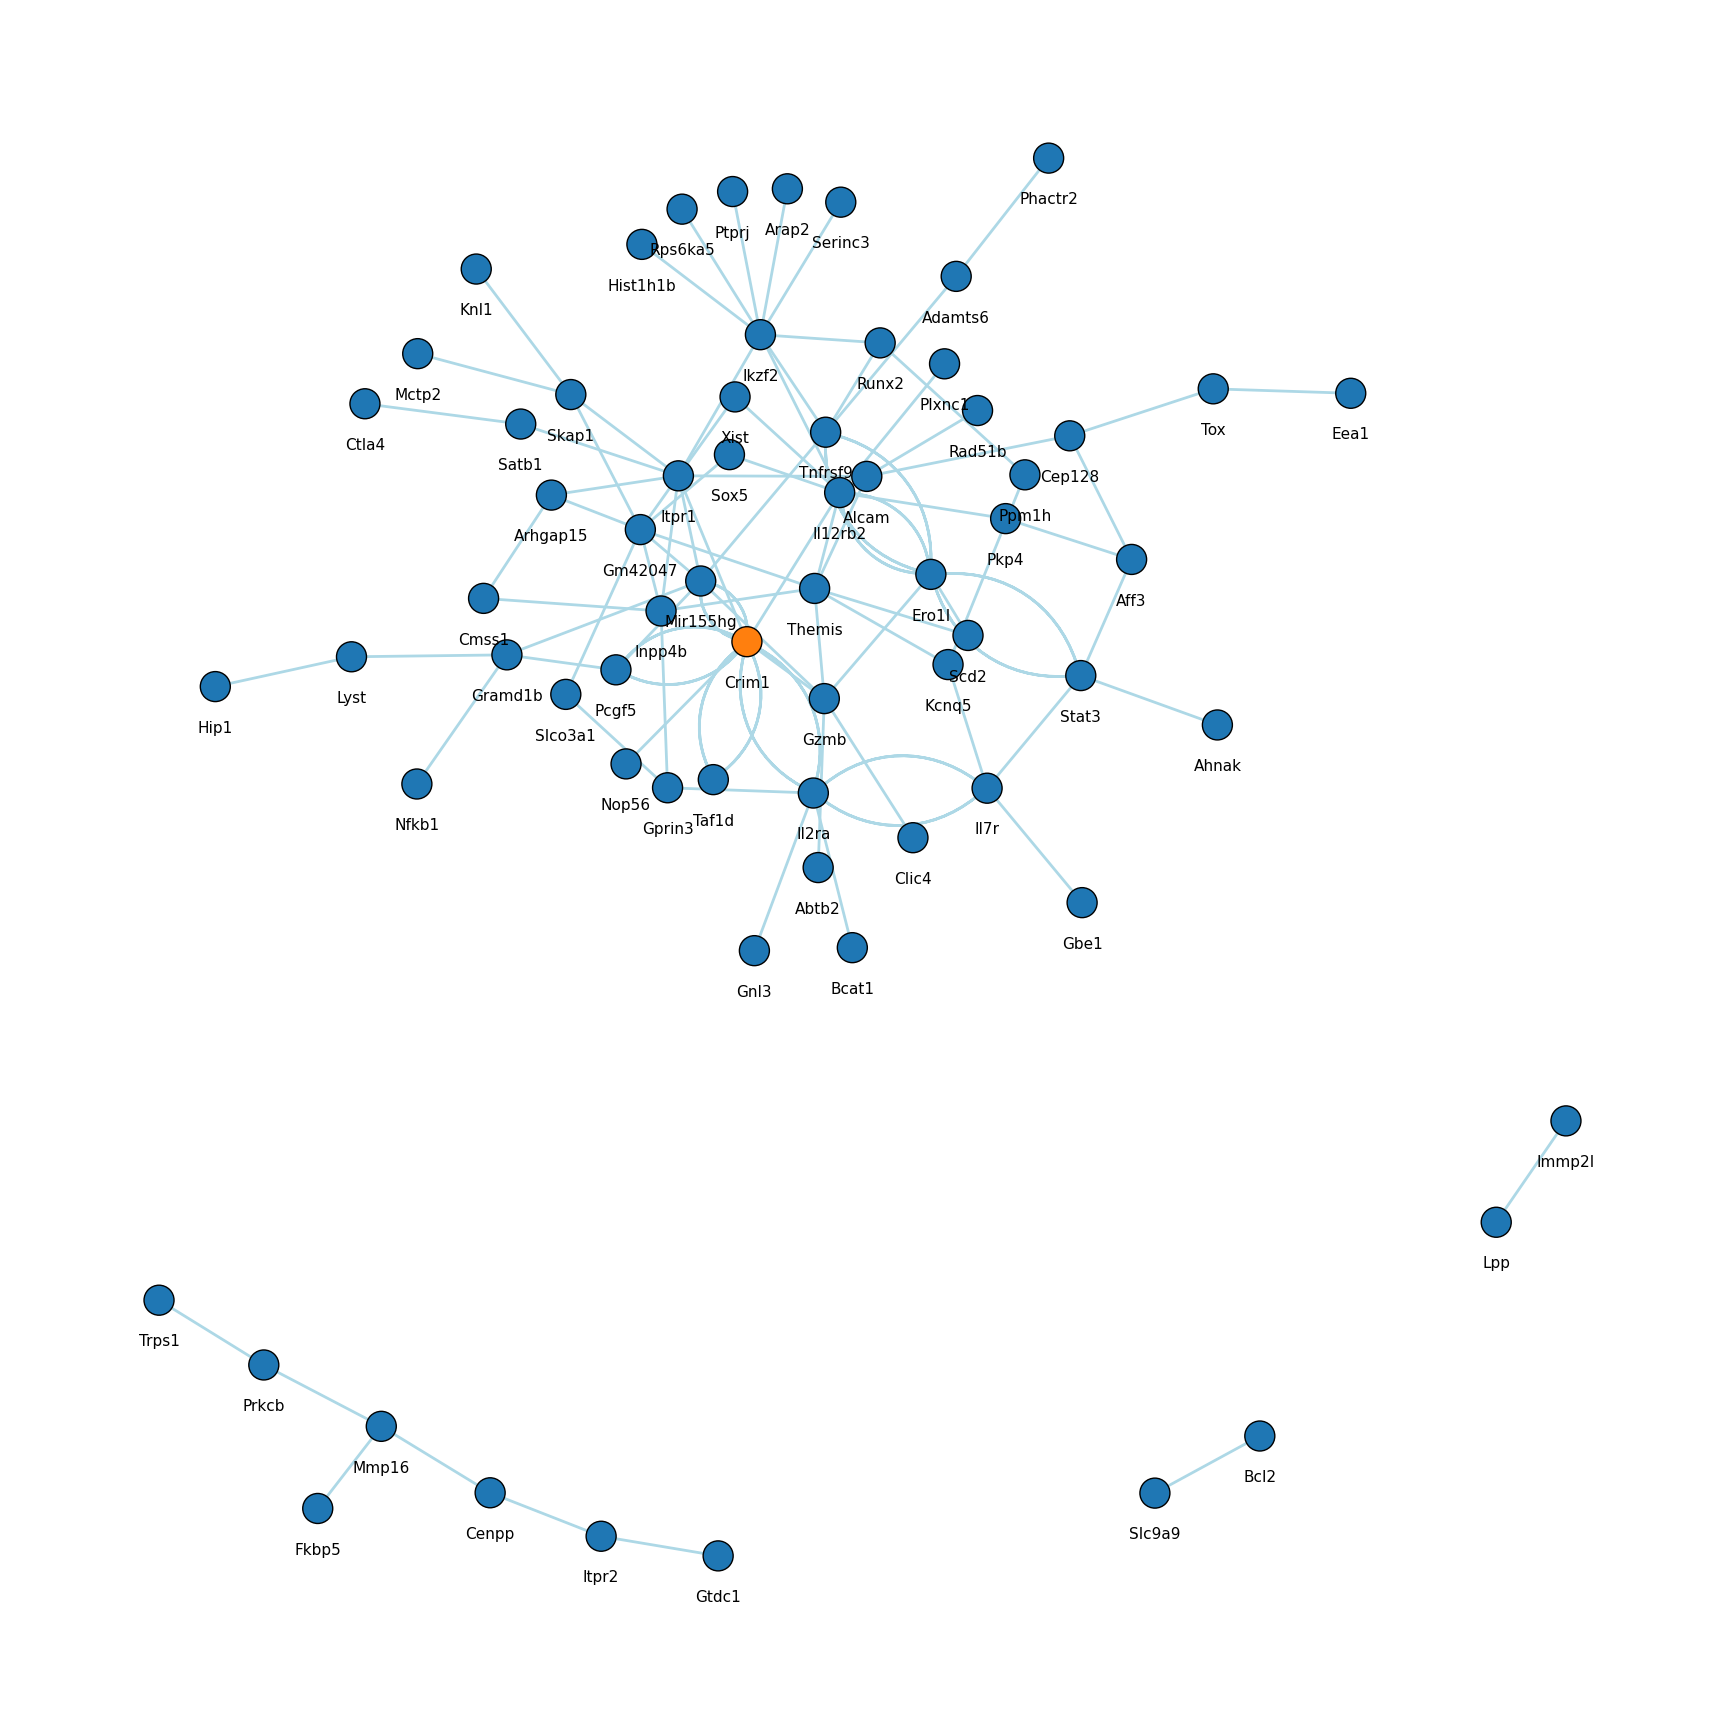

In [36]:
filtered_df = all_regulons[(all_regulons.set_type == 'unique') & (all_regulons.cluster == '0')].nlargest(100,'sum_of_edge')
make_single_celltype_graph(filtered_df, tfs = set(['Crim1']))

## Extract the largest module of TFs from the network
This function works only if you have a list of transcription factors to pass.
Otherwise it will return an empty net. The function extracts the largest connected component which contains most of the genes in the list.

In [37]:
import igraph as ig
import matplotlib.pyplot as plt


def extract_tf_subgraph(filtered_df, tfs):
    
    g = ig.Graph.TupleList(filtered_df[['source', 'target', 'sum_of_edge']].itertuples(index=False), directed=False, weights=True)

    # 7. LAYOUT & PLOTTING
    #layout = g.layout_kamada_kawai()

    if tfs is not None:
        g.vs["is_tf"] = [name in tfs for name in g.vs["name"]]
        colors = ["#ff7f0e" if is_tf else "#1f77b4" for is_tf in g.vs["is_tf"]]
    else:
        colors = ["#ff7f0e" for node in g.vs["is_tf"]]


    tf_indices = [v.index for v in g.vs if v["is_tf"]]
    tf_subgraph = g.subgraph(tf_indices)

    # 2. Get the largest connected component
    components = tf_subgraph.connected_components(mode='weak')
    giant_component = components.giant()

    # --- FIX: Ensure the weight attribute exists ---
    # If 'sum_of_edge' is missing, it might be stored simply as 'weight' 
    # because of how TupleList was initialized.
    attr_name = 'sum_of_edge' if 'sum_of_edge' in giant_component.es.attributes() else 'weight'

    try:
        edge_weights = giant_component.es[attr_name]
    except KeyError:
        # Fallback if no weights exist at all
        edge_weights = [1] * len(giant_component.es)

    # 3. Plotting
    layout = giant_component.layout_kamada_kawai()
    fig, ax = plt.subplots(figsize=(8, 8))

    ig.plot(
        giant_component,
        target=ax,
        layout=layout,
        vertex_size=25,
        vertex_color="#ff7f0e", 
        vertex_label=giant_component.vs["name"],
        vertex_label_size=12,
        vertex_label_dist=2.0,
        edge_alpha=1,

        edge_arrow_size=0.5
    )

    plt.title("Largest Connected TF Regulatory Module", fontsize=20)
    plt.show()

## Make a GRN interface plot 
In this plot you can see genes between the two networks and the ones that are only part of one network.

In [123]:
from netmap.masking.internal import add_cluster_wise_spearman
from netmap.downstream.regulon import select_top_edges_signed

# Step 1: annotate edges with cluster-wise Spearman correlation
grn_adata = add_cluster_wise_spearman(grn_adata, adata_raw, cluster_column='leiden')

# Step 2: select signed regulons

keep_edges_positive = select_top_edges_signed(
    grn_adata,
    top_per_source=10,
    col_cluster='leiden',
    min_reg_size=1,
     min_edge_support=0.5,
    neutral_threshold=0.05,
)



Selecting targets for cluster: 0
Selecting targets for cluster: 1
Selecting targets for cluster: 2
Selecting targets for cluster: 3


In [73]:
# This function can be used to transform the dictionary into a dataframe. 
all_regulons = make_cluster_regulon_dataframe_directional(keep_edges_positive)


,source,target,sum_of_edge,spearman,cluster,set_type,direction
0,Arhgap18,Runx2,0.004004,0.067047,0,unique,positive
1,Nedd9,Tnfrsf9,0.006860,0.054222,0,unique,positive
2,Knl1,Inpp4b,0.017151,0.095806,0,unique,positive
3,Gtdc1,Bcl2,0.011309,0.097316,0,unique,positive
4,Adamts6,Rad51b,0.013351,0.071714,0,unique,positive
...,...,...,...,...,...,...,...
59,Retreg1,Skap1,0.005490,-0.056696,3,all,negative
60,Runx1,Fyb,0.011880,-0.064033,3,all,negative
61,Add3,Slc9a9,0.006602,-0.053936,3,all,negative
62,Gab3,Mmp16,0.005734,-0.054002,3,all,negative


In [ ]:
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

POSITIVE_EDGE_COLOR = "#de7a7b"  # red
NEGATIVE_EDGE_COLOR = "#6baedb"  # blue
NEUTRAL_EDGE_COLOR = "#cccccc"


def create_inferface_graph(filtered_df, target_clusters, combo_colors, top_edges=400,
                            min_edge_width=0.5, max_edge_width=6.0):

    filtered_df = filtered_df[
        (filtered_df.set_type == 'unique') &
        (filtered_df.cluster.isin(target_clusters))
    ].groupby('cluster', group_keys=False).apply(
        lambda x: x.loc[x['sum_of_edge'].abs().nlargest(top_edges).index]
    )
    print(filtered_df)
    target_clusters_by_name = filtered_df.groupby('target')['cluster'].apply(set).to_dict()
    source_clusters_by_name = filtered_df.groupby('source')['cluster'].apply(set).to_dict()

    # union of clusters a node participates in, whether as source or target
    node_clusters = {}
    for name in set(target_clusters_by_name) | set(source_clusters_by_name):
        node_clusters[name] = target_clusters_by_name.get(name, set()) | source_clusters_by_name.get(name, set())
    node_combos = {name: " & ".join(sorted(clusters)) for name, clusters in node_clusters.items()}

    def get_color(name):
        combo_string = node_combos.get(name, "")
        if combo_string in combo_colors:
            return combo_colors[combo_string]
        elif " & " in combo_string:
            return "#7f7f7f"  # Grey for any intersection not explicitly defined above
        else:
            return "#e0e0e0"  # Light Grey for nodes with no matching combo

    g = ig.Graph.TupleList(
        filtered_df[['source', 'target', 'spearman']].itertuples(index=False),
        directed=True, weights=True
    )
    g.vs["color"] = [get_color(name) for name in g.vs["name"]]

    # width: correlation strength (magnitude of spearman)
    spearman_vals = np.array(g.es["weight"], dtype=float)
    max_abs = np.nanmax(np.abs(spearman_vals)) if len(spearman_vals) else 0
    # if max_abs > 0:
    #     g.es["width"] = min_edge_width + (max_edge_width - min_edge_width) * np.nan_to_num(np.abs(spearman_vals)) / max_abs
    # else:
    #     g.es["width"] = min_edge_width

    # color: net attribution direction (sign of the value used to select edges),
    # since ranking by |sum_of_edge| discards the sign that determined it
    edge_sum_vals = np.array(g.es["weight"], dtype=float)

    g.es["color"] = [
        POSITIVE_EDGE_COLOR if s > 0 else NEGATIVE_EDGE_COLOR if s < 0 else NEUTRAL_EDGE_COLOR
        for s in edge_sum_vals
    ]

    components = g.connected_components(mode='weak')
    giant_component = components.giant()

    layout = giant_component.layout_kamada_kawai()
    fig, ax = plt.subplots(figsize=(16, 14))
    plt.subplots_adjust(right=0.75)

    ig.plot(
        giant_component,
        layout=layout,
        target=ax,
        vertex_size=12,
        vertex_color=giant_component.vs["color"],
        vertex_label=giant_component.vs["name"],
        vertex_label_size=8,
        #edge_width=giant_component.es["width"],
        edge_color=giant_component.es["color"],
        edge_alpha=0.6,
        edge_arrow_size=0.8,
        edge_arrow_width=0.8,
        edge_curved=0.1,
    )

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=k, markerfacecolor=v, markersize=8)
        for k, v in combo_colors.items()
    ]
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label='Unassigned',
                                   markerfacecolor='#e0e0e0', markersize=8))
    legend_elements.append(Line2D([0], [0], color=POSITIVE_EDGE_COLOR, lw=3, label='Positive spearman corr'))
    legend_elements.append(Line2D([0], [0], color=NEGATIVE_EDGE_COLOR, lw=3, label='Negative spearman corr'))

    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Cell Type Groups")
    plt.show()


       source   target  sum_of_edge  spearman cluster set_type direction  \
972   Gm42418   Lgals1     0.151168  0.061490       1   unique  positive   
544   Gm42418  Gm10076     0.112605  0.053520       1   unique  positive   
607      Aff3  Phactr2     0.044406  0.164573       1   unique  positive   
86       Aff3    Fgf13     0.043894  0.197817       1   unique  positive   
1598    Fgf13     Aff3     0.043273  0.197817       1   unique  positive   
...       ...      ...          ...       ...     ...      ...       ...   
235     Cmss1  Tnfrsf9    -0.002425 -0.059435       2   unique  negative   
170    Ipcef1  Adamts6     0.021858  0.101483       2   unique  positive   
170    Hivep2     Xcl1     0.014044 -0.062192       2   unique  negative   
49     Slamf1  Adamts6     0.021765  0.084755       2   unique  positive   
49      Susd6    Snhg3     0.003276 -0.052743       2   unique  negative   

      abs_edge  
972   0.151168  
544   0.112605  
607   0.044406  
86    0.043894  
15

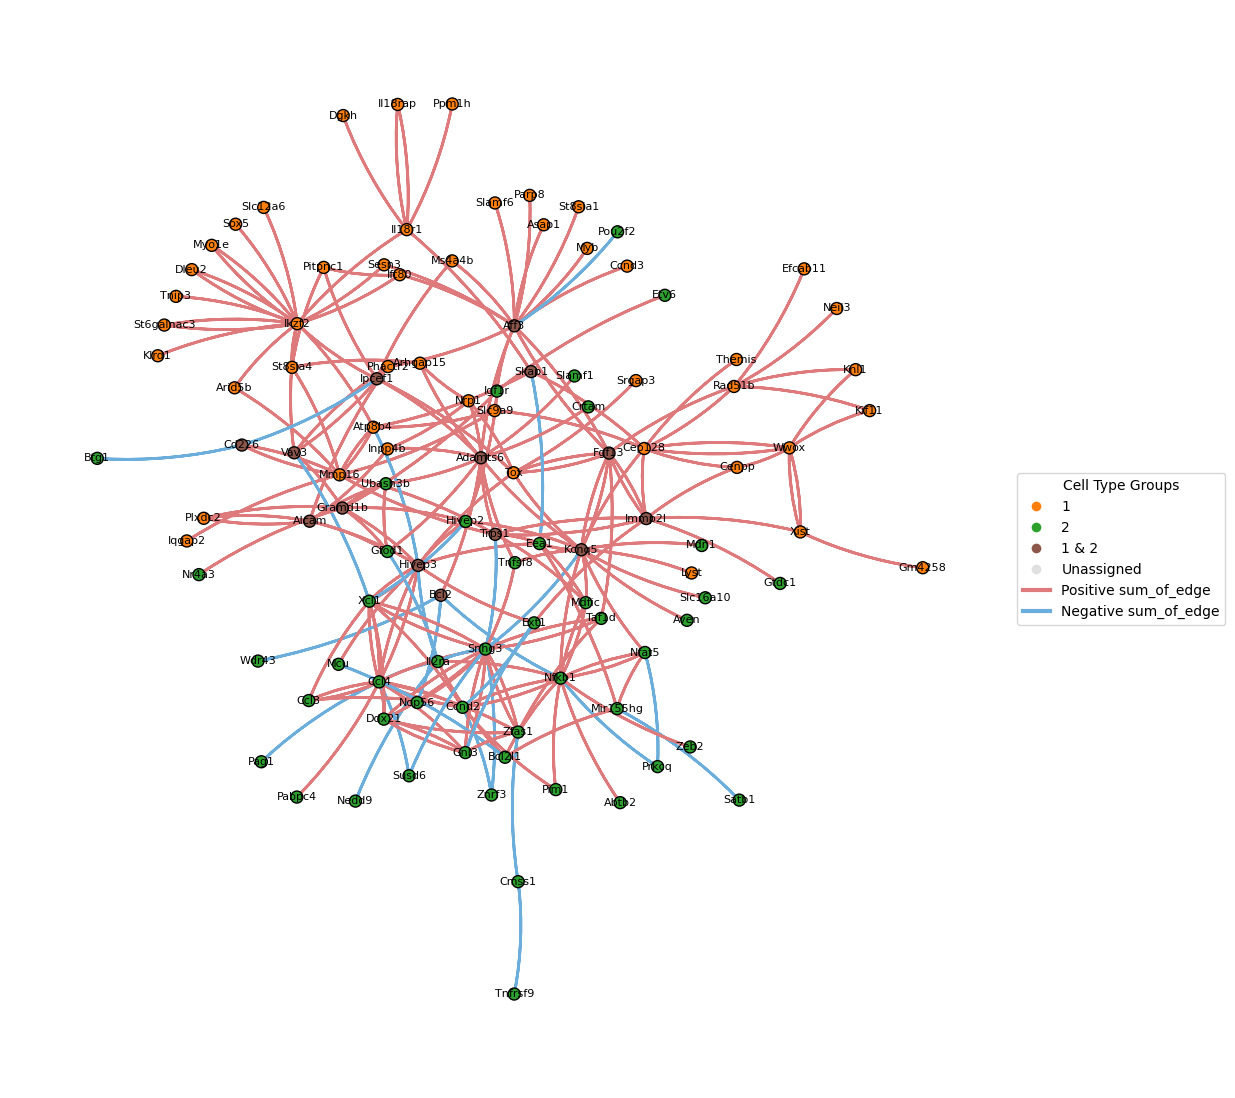

In [127]:
target_clusters = ['1', '2']
combo_colors = {
    # Individual "Core 3" (Originals)
    target_clusters[0]: '#ff7f0e',            # Orange
    target_clusters[1]: '#2ca02c',            # Green
    f'{target_clusters[0]} & {target_clusters[1]}': '#8c564b', # Brown
        #f'{target_clusters[0]} & {target_clusters[1]}' : 'pink', # Brown
}

create_inferface_graph(all_regulons, ['1', '2'], combo_colors, top_edges=100)